In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ── 全局绘图风格（研报级）──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'SimHei',
    'axes.unicode_minus': False,
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'legend.fontsize':    8,
    'legend.framealpha':  0.8,
})

# ── 颜色主题 ──────────────────────────────────────────────────────────────
C = dict(
    index   = '#2C3E50',   # 深蓝灰：指数
    bull    = '#C0392B',   # 深红：多头/信号1
    bear    = '#2980B9',   # 蓝：空头
    sig2    = '#E67E22',   # 橙：信号2
    bench   = '#7F8C8D',   # 灰：基准
    factor  = '#8E44AD',   # 紫：因子
    dd      = '#E74C3C',   # 红：回撤
    green   = '#27AE60',   # 绿
    yellow  = '#F1C40F',   # 黄
)

# 设置中文字体
font_path = "C:/Windows/Fonts/simhei.ttf"
font_prop = font_manager.FontProperties(fname=font_path)
matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

TRADING_DAYS = 252

## 1  数据预处理

In [15]:
# ── 1.1 国证全A 日线数据 ─────────────────────────────────────────────────
df = pd.read_csv('index_hist_cni_399317.csv', parse_dates=['日期'])
df = (df.sort_values('日期').set_index('日期')
        .rename(columns={'开盘价':'open','最高价':'high','最低价':'low',
                         '收盘价':'close','涨跌幅':'pct_chg',
                         '成交量':'volume','成交额':'amount'}))
df['ret'] = df['pct_chg']
close = df['close']

# ── 1.2 50ETF 期权隐含波动率 ──────────────────────────────────────────────
implied_volatility = pd.read_csv('50ETF_ImpliedVolatility.csv',
                                  parse_dates=['TRADE_DATE'])

# ── 1.3 A股成分股日线（用于涨停占比因子）───────────────────────────────────
constituent_stock = pd.read_csv('A_stock_daily_2010_2025_hfq.csv',
                                 parse_dates=['date'])

print(f'指数数据：{df.index[0].date()} — {df.index[-1].date()}，共 {len(df)} 行')
print(f'期权数据：{implied_volatility.shape[0]} 行')
print(f'成分股数据：{constituent_stock.shape[0]} 行')
df.head(3)

指数数据：2010-01-04 — 2025-12-31，共 3886 行
期权数据：335460 行
成分股数据：12320871 行


,open,high,low,close,pct_chg,volume,amount,ret
日期,,,,,,,,
2010-01-04,3311.7279,3316.1241,3276.2273,3276.2273,-0.006,15678.34,2069.70,-0.006
2010-01-05,3283.1592,3309.1449,3245.8613,3305.7476,0.009,18735.01,2549.08,0.009
2010-01-06,3301.4769,3327.4824,3288.7061,3289.3477,-0.005,18338.14,2503.23,-0.005


## 2  核心框架

In [16]:
# ── 2.1 绩效统计 ─────────────────────────────────────────────────────────
def calc_stats(bt_df: pd.DataFrame, nav: pd.Series) -> dict:
    r   = bt_df['ret'].dropna()
    dd  = nav / nav.cummax() - 1
    n   = max(len(nav) - 1, 1)
    ann_ret = nav.iloc[-1] ** (TRADING_DAYS / n) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(TRADING_DAYS)
    sharpe  = (r.mean() / r.std(ddof=0) * np.sqrt(TRADING_DAYS)
               if r.std(ddof=0) > 0 else np.nan)
    max_dd  = dd.min()
    calmar  = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

    pos    = bt_df['pos'].fillna(0).astype(int)
    run_id = (pos != pos.shift(1)).cumsum()
    hold_lens    = pos.groupby(run_id).size()
    hold_nonzero = hold_lens[pos.groupby(run_id).first() != 0]

    pnls = [nav.loc[g.index[-1]] / nav.loc[g.index[0]] - 1
            for _, g in bt_df.groupby(run_id) if g['pos'].iloc[0] != 0]
    pnls = pd.Series(pnls)
    win  = float((pnls > 0).mean()) if len(pnls) else np.nan
    odds = (float(pnls[pnls>0].mean() / abs(pnls[pnls<0].mean()))
            if (pnls>0).any() and (pnls<0).any() else np.nan)

    return {'年化收益': ann_ret, '年化波动': ann_vol, '最大回撤': max_dd,
            '夏普比率': sharpe,  'Calmar比率': calmar,
            '持仓均值': float(hold_nonzero.mean()) if len(hold_nonzero) else np.nan,
            '持仓中位': float(hold_nonzero.median()) if len(hold_nonzero) else np.nan,
            '胜率': win, '赔率': odds, '段数': int(len(pnls))}


# ── 2.2 回测引擎 ──────────────────────────────────────────────────────────
def backtest(close: pd.Series, signal: pd.Series,
             cost_bps: float = 0.0) -> pd.DataFrame:
    """T日信号，T+1日收盘价调仓，双边费率 cost_bps（单位：bps）"""
    close  = close.dropna()
    signal = signal.reindex(close.index).fillna(0)
    ret    = close.pct_change().fillna(0)
    pos    = signal.shift(1).fillna(0)
    strat  = pos.shift(1).fillna(0) * ret
    if cost_bps > 0:
        cost   = pos.diff().abs().fillna(0) * (cost_bps / 1e4)
        strat -= cost.shift(1).fillna(0)
    nav = (1 + strat).cumprod()
    return pd.DataFrame({'ret': strat, 'nav': nav, 'pos': pos})


# ── 2.3 因子指标库 ────────────────────────────────────────────────────────
def bias(x: pd.Series, n: int) -> pd.Series:
    """乖离率 = (x / MA_n - 1) × 100"""
    return (x / x.rolling(n, min_periods=n).mean() - 1) * 100

def smooth(f: pd.Series, n: int) -> pd.Series:
    return f if n <= 1 else f.rolling(n, min_periods=n).mean()

def bollinger_band(x: pd.Series, n=20, k=2.0) -> pd.DataFrame:
    mid = x.rolling(n, min_periods=n).mean()
    std = x.rolling(n, min_periods=n).std(ddof=0)
    return pd.DataFrame({'mid': mid, 'upper': mid+k*std, 'lower': mid-k*std})

def adx(high, low, close, n=20) -> pd.Series:
    h, l, c = high.astype(float), low.astype(float), close.astype(float)
    tr = pd.concat([h-l, (h-c.shift(1)).abs(), (l-c.shift(1)).abs()],
                   axis=1).max(axis=1)
    um, dm = h.diff(), -l.diff()
    pdm = pd.Series(np.where((um>dm)&(um>0), um, 0.), index=h.index)
    mdm = pd.Series(np.where((dm>um)&(dm>0), dm, 0.), index=h.index)
    a   = 1/n
    atr = tr.ewm(alpha=a, adjust=False).mean()
    pdi = 100*pdm.ewm(alpha=a,adjust=False).mean()/atr
    mdi = 100*mdm.ewm(alpha=a,adjust=False).mean()/atr
    dx  = 100*(pdi-mdi).abs()/(pdi+mdi)
    return dx.ewm(alpha=a, adjust=False).mean()

def new_high_ratio(close: pd.Series, n=20) -> pd.Series:
    """过去N日内创N日新高的天数占比（%）"""
    roll_max   = close.rolling(n, min_periods=n).max()
    is_nh      = (close == roll_max).astype(int)
    return is_nh.rolling(n, min_periods=n).sum() / n * 100

def implied_vol_factor(iv: pd.Series, n=20) -> pd.Series:
    """50ETF 每日平均隐含波动率的N日均值"""
    return iv.astype(float).rolling(n, min_periods=n).mean()

def limit_up_ratio(limit_up_cnt: pd.Series, total: int, n=5) -> pd.Series:
    """成分股涨停家数占比的N日均值（%）"""
    return (limit_up_cnt.astype(float) / total * 100).rolling(n, min_periods=n).mean()


# ── 2.4 信号生成器 ────────────────────────────────────────────────────────
def make_signal(factor: pd.Series, stype: str,
                lookback=20, k=1.0, q=0.8) -> pd.Series:
    """统一信号生成：MOM / BOLL / RBOLL / PERF / RPERF / SMA"""
    if stype == 'MOM':
        return np.sign(factor - factor.shift(lookback)).fillna(0).astype(int)
    if stype == 'SMA':
        ma = factor.rolling(lookback, min_periods=lookback).mean()
        return ((factor > ma).astype(int)*2 - 1)
    mid = factor.rolling(lookback, min_periods=lookback).mean()
    std = factor.rolling(lookback, min_periods=lookback).std(ddof=0)
    if stype in ('BOLL','RBOLL'):
        sig = pd.Series(np.nan, index=factor.index)
        sig[factor > mid+k*std] = 1.; sig[factor < mid-k*std] = -1.
        sig = sig.ffill().fillna(0).astype(int)
        return -sig if stype == 'RBOLL' else sig
    if stype in ('PERF','RPERF'):
        hi = factor.rolling(lookback,min_periods=lookback).quantile(q)
        lo = factor.rolling(lookback,min_periods=lookback).quantile(1-q)
        sig = pd.Series(np.nan, index=factor.index)
        sig[factor>=hi]=1.; sig[factor<=lo]=-1.
        sig = sig.ffill().fillna(0).astype(int)
        return -sig if stype == 'RPERF' else sig
    raise ValueError(stype)


# ── 2.5 统一回测封装 ──────────────────────────────────────────────────────
def run_strategy(close, factor, stype, smooth_n=1, lookback=20,
                 k=1.0, q=0.8, cost_bps=5.0, name='Factor') -> dict:
    fs  = smooth(factor.reindex(close.index), smooth_n)
    sig = make_signal(fs, stype, lookback, k=k, q=q)
    bt  = backtest(close, sig, cost_bps=cost_bps/1e4)
    st  = calc_stats(bt, bt['nav'])
    st.update(name=name, stype=stype, smooth_n=smooth_n, lookback=lookback)
    return dict(stats=st, bt=bt, nav=bt['nav'], factor=fs, signal=sig, close=close)

print('框架加载完毕 ✓')

框架加载完毕 ✓


## 3  单指标回测

> 回测区间 2010/1/4—2025/12/19，T+1 调仓，双边费率 0.05%

In [24]:
# ── 3.0 共用绘图函数 ─────────────────────────────────────────────────────
def plot_factor_backtest(res: dict, factor_label: str,
                         factor_unit: str = '', fc: str = None):
    """标准三图：因子走势 / 净值+回撤 / 仓位"""
    fc   = fc or C['factor']
    nav  = res['nav']
    bt   = res['bt']
    cl   = res['close']
    dd   = nav / nav.cummax() - 1
    sig  = res['signal']
    fac  = res['factor'].reindex(cl.index)
    norm = cl / cl.iloc[0]

    fig = plt.figure(figsize=(13, 9))
    gs  = GridSpec(3, 1, figure=fig, hspace=0.45)

    # ── 图1：指数 vs 因子 ────────────────────────────────────────────────
    ax1  = fig.add_subplot(gs[0])
    ax1r = ax1.twinx()
    ax1.plot(cl.index.to_numpy(), cl.values, color=C['index'], lw=1.2, label='国证全A')
    ax1r.plot(fac.index.to_numpy(), fac.values, color=fc, lw=1.0, alpha=0.8,
              label=factor_label)
    ax1r.spines['right'].set_visible(True)
    ax1.set_ylabel('指数点位');  ax1r.set_ylabel(factor_unit or factor_label)
    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax1r.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left')
    ax1.set_title(f'国证全A 与 {factor_label} 因子走势对比', fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # ── 图2：净值 + 回撤 ─────────────────────────────────────────────────
    ax2  = fig.add_subplot(gs[1])
    ax2r = ax2.twinx()
    ax2.plot(norm.index.to_numpy(), norm.values, color=C['bench'], lw=1.0,
             ls='--', label='买入持有')
    ax2.plot(nav.index.to_numpy(),  nav.values,  color=C['bull'],  lw=1.4,
             label='择时策略')
    ax2r.fill_between(dd.index.to_numpy(), dd.values*100, 0,
                      color=C['dd'], alpha=0.20, label='回撤')
    ax2r.set_ylabel('回撤 (%)')
    ax2r.spines['right'].set_visible(True)
    ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax2.set_ylabel('净值')
    h1,l1=ax2.get_legend_handles_labels(); h2,l2=ax2r.get_legend_handles_labels()
    ax2.legend(h1+h2, l1+l2, loc='upper left')
    ax2.set_title('策略净值 vs 买入持有', fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # ── 图3：持仓信号 ────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    sv  = sig.reindex(cl.index).fillna(0).values
    barcols = [C['bull'] if v==1 else (C['bear'] if v==-1 else '#BDC3C7')
               for v in sv]
    ax3.bar(cl.index, sv, width=1, color=barcols, alpha=0.55)
    ax3.set_ylim(-1.6, 1.6)
    ax3.set_ylabel('仓位 {+1 / 0 / -1}')
    ax3.set_title('择时仓位', fontweight='bold')
    ax3.set_xticks([])

    # ── 绩效注释 ────────────────────────────────────────────────────────
    st = res['stats']
    txt = (f"年化收益 {st['年化收益']:+.1%}  |  "
           f"夏普 {st['夏普比率']:.2f}  |  "
           f"最大回撤 {st['最大回撤']:.1%}  |  "
           f"Calmar {st['Calmar比率']:.2f}  |  "
           f"胜率 {st['胜率']:.1%}  赔率 {st['赔率']:.2f}")
    fig.text(0.5, 0.01, txt, ha='center', fontsize=8,
             color='#444', style='italic')
#     plt.savefig(f'/tmp/{factor_label}.png', bbox_inches='tight')
    plt.show()

print('绘图函数加载完毕 ✓')

绘图函数加载完毕 ✓


### 3.1  BIAS20 — 20日价格乖离率

**择时逻辑**：乖离率反映价格偏离20日均线的程度，乖离率动量上升→看多（趋势跟踪）。

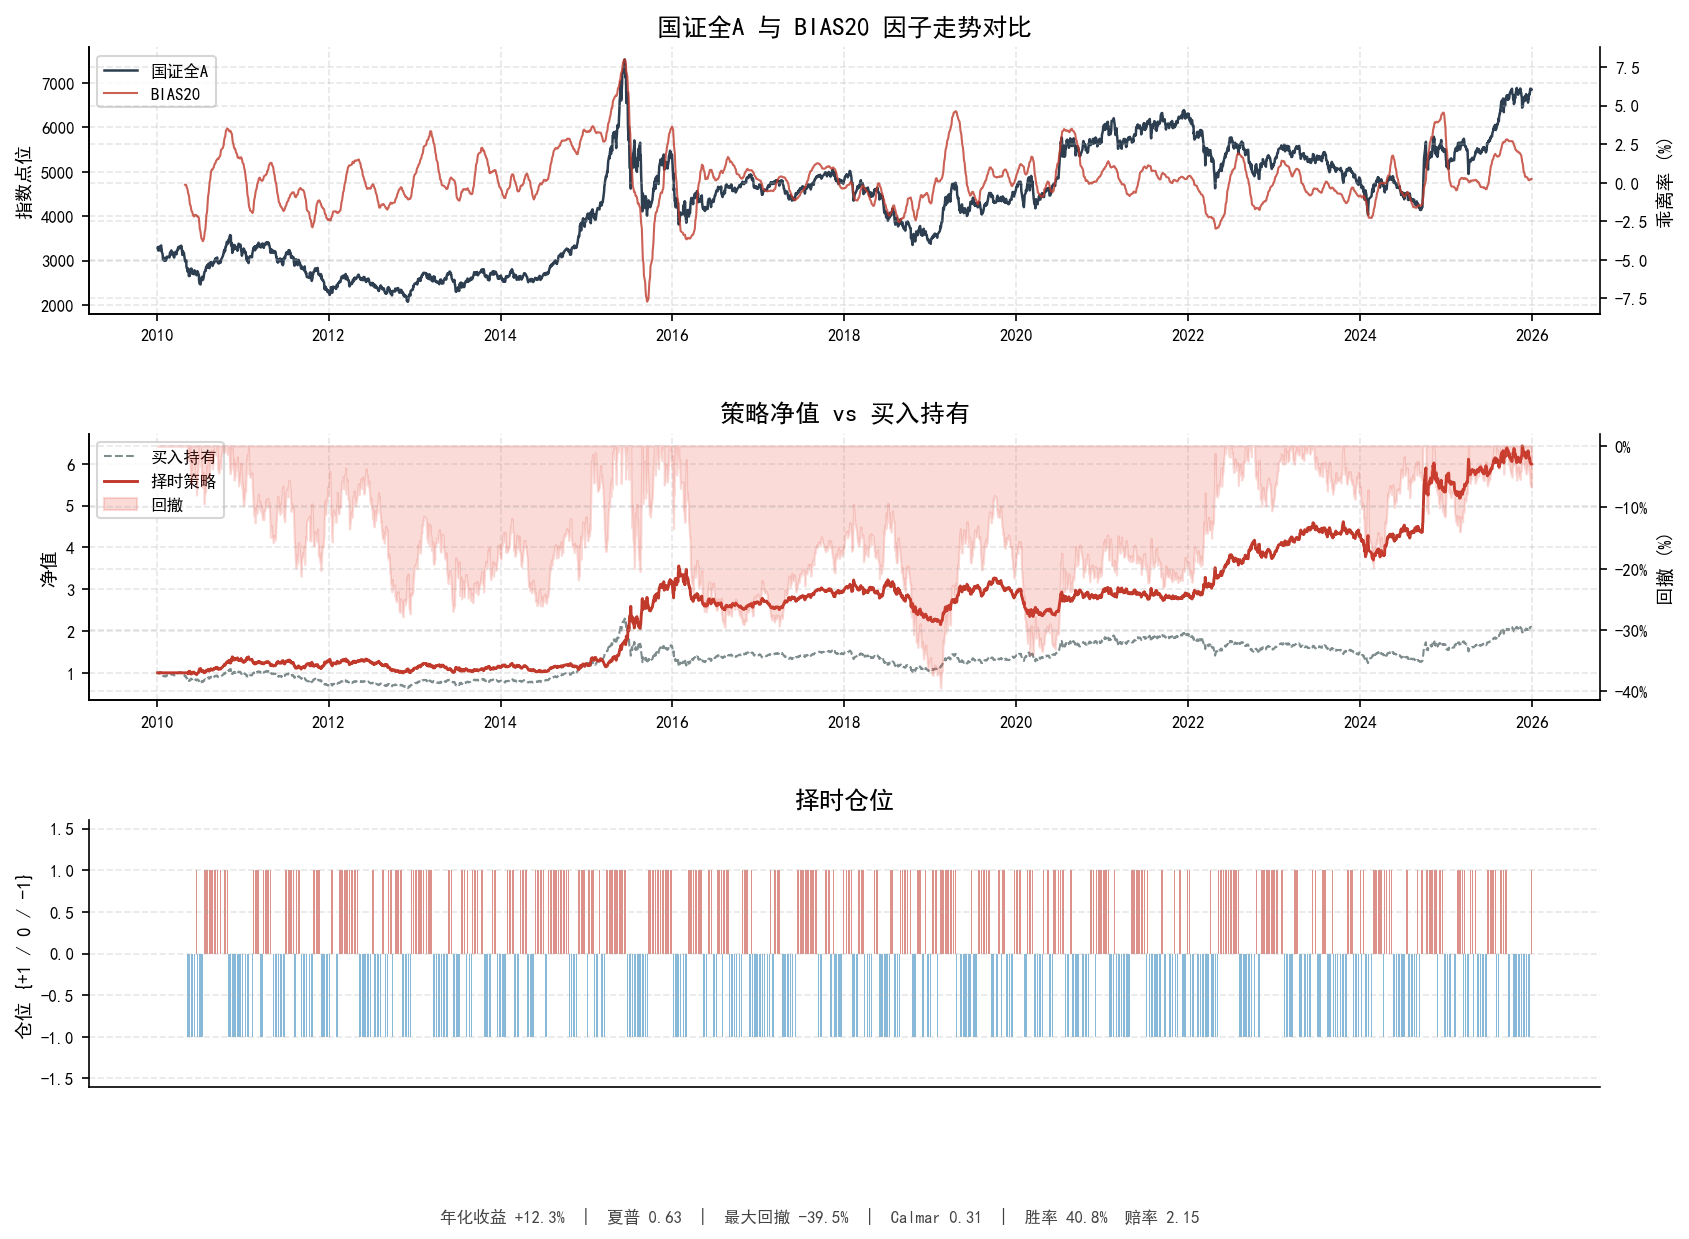

In [25]:
factor_bias20 = bias(close, 20)
res1 = run_strategy(close, factor_bias20, 'MOM', smooth_n=60, lookback=5,
                    cost_bps=5.0, name='BIAS20')
plot_factor_backtest(res1, 'BIAS20', '乖离率 (%)', C['bull'])

### 3.2  BOLL20 — 20日布林带

**择时逻辑**：价格偏离度突破±2σ通道→信号，跟踪价格二阶变化。

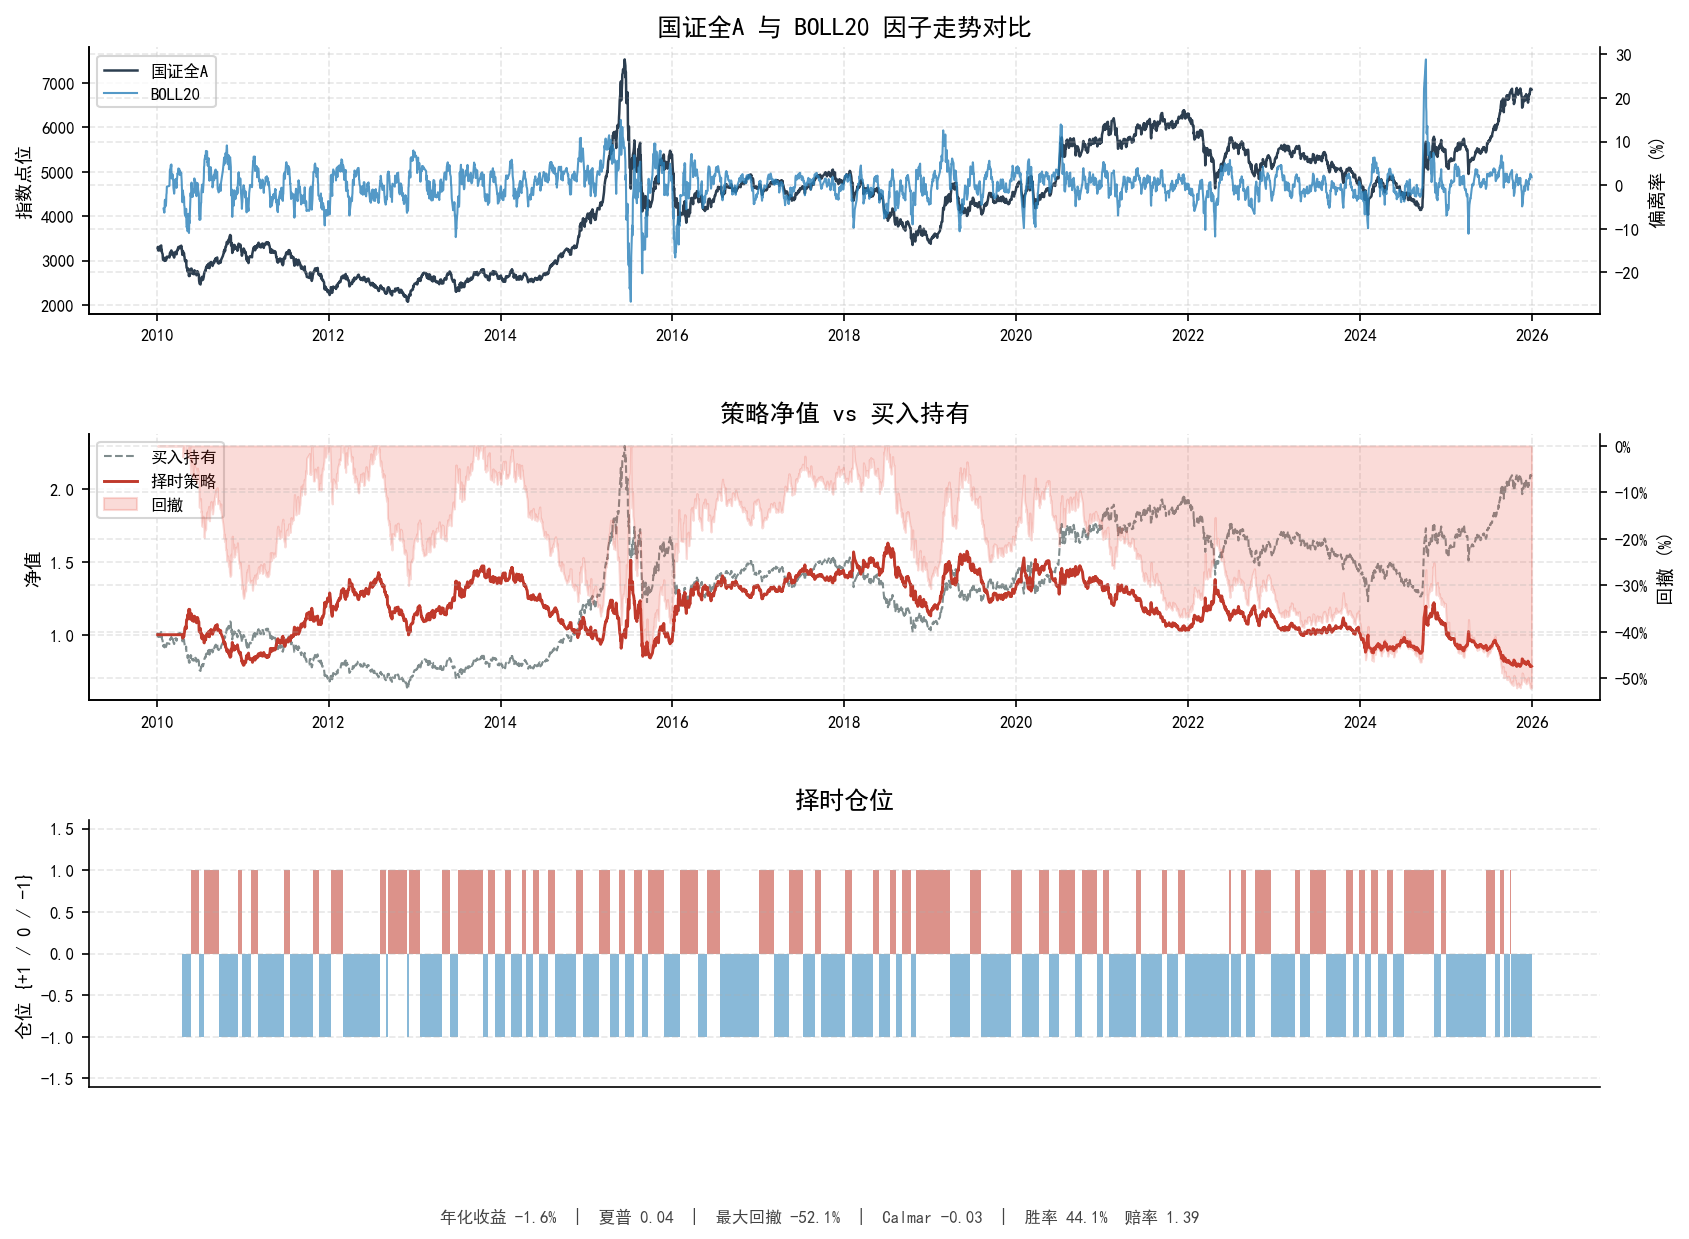

In [23]:
boll = bollinger_band(close, n=20, k=2.0)
factor_boll20 = (close - boll['mid']) / boll['mid'] * 100
res2 = run_strategy(close, factor_boll20, 'BOLL', smooth_n=1, lookback=20,
                    k=2.0, cost_bps=5.0, name='BOLL20')
plot_factor_backtest(res2, 'BOLL20', '偏离率 (%)', C['bear'])

### 3.3  ADX20 — 20日趋势强度

**择时逻辑**：ADX趋势强度均线突破→趋势加速做多，减缓做空。

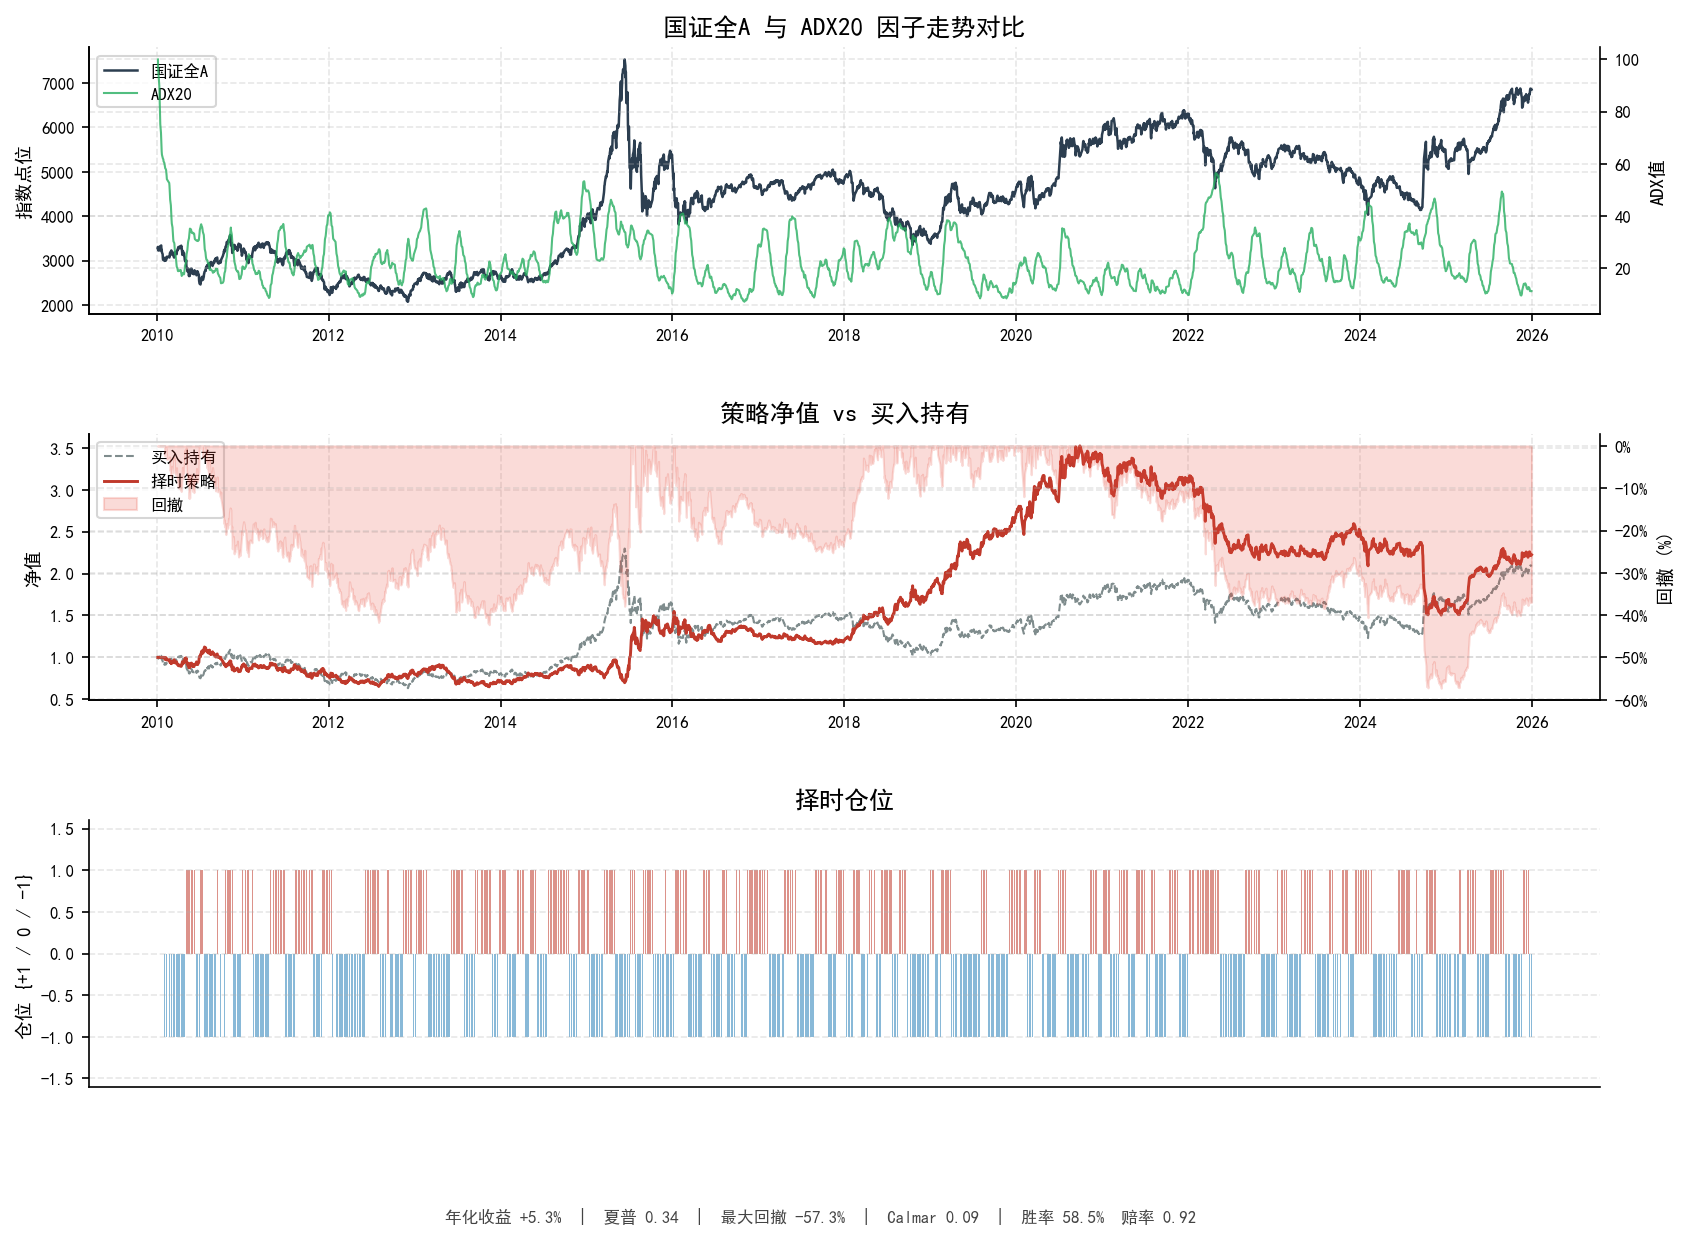

In [26]:
factor_adx20 = adx(df['high'], df['low'], df['close'], n=20)
res3 = run_strategy(close, factor_adx20, 'BOLL', smooth_n=1, lookback=20,
                    k=1.0, cost_bps=5.0, name='ADX20')
plot_factor_backtest(res3, 'ADX20', 'ADX值', C['green'])

### 3.4  NH_RATIO20 — 20日创新高天数占比

**择时逻辑**：过去20日内创N日新高天数占比高→上升趋势持续，仅做多。

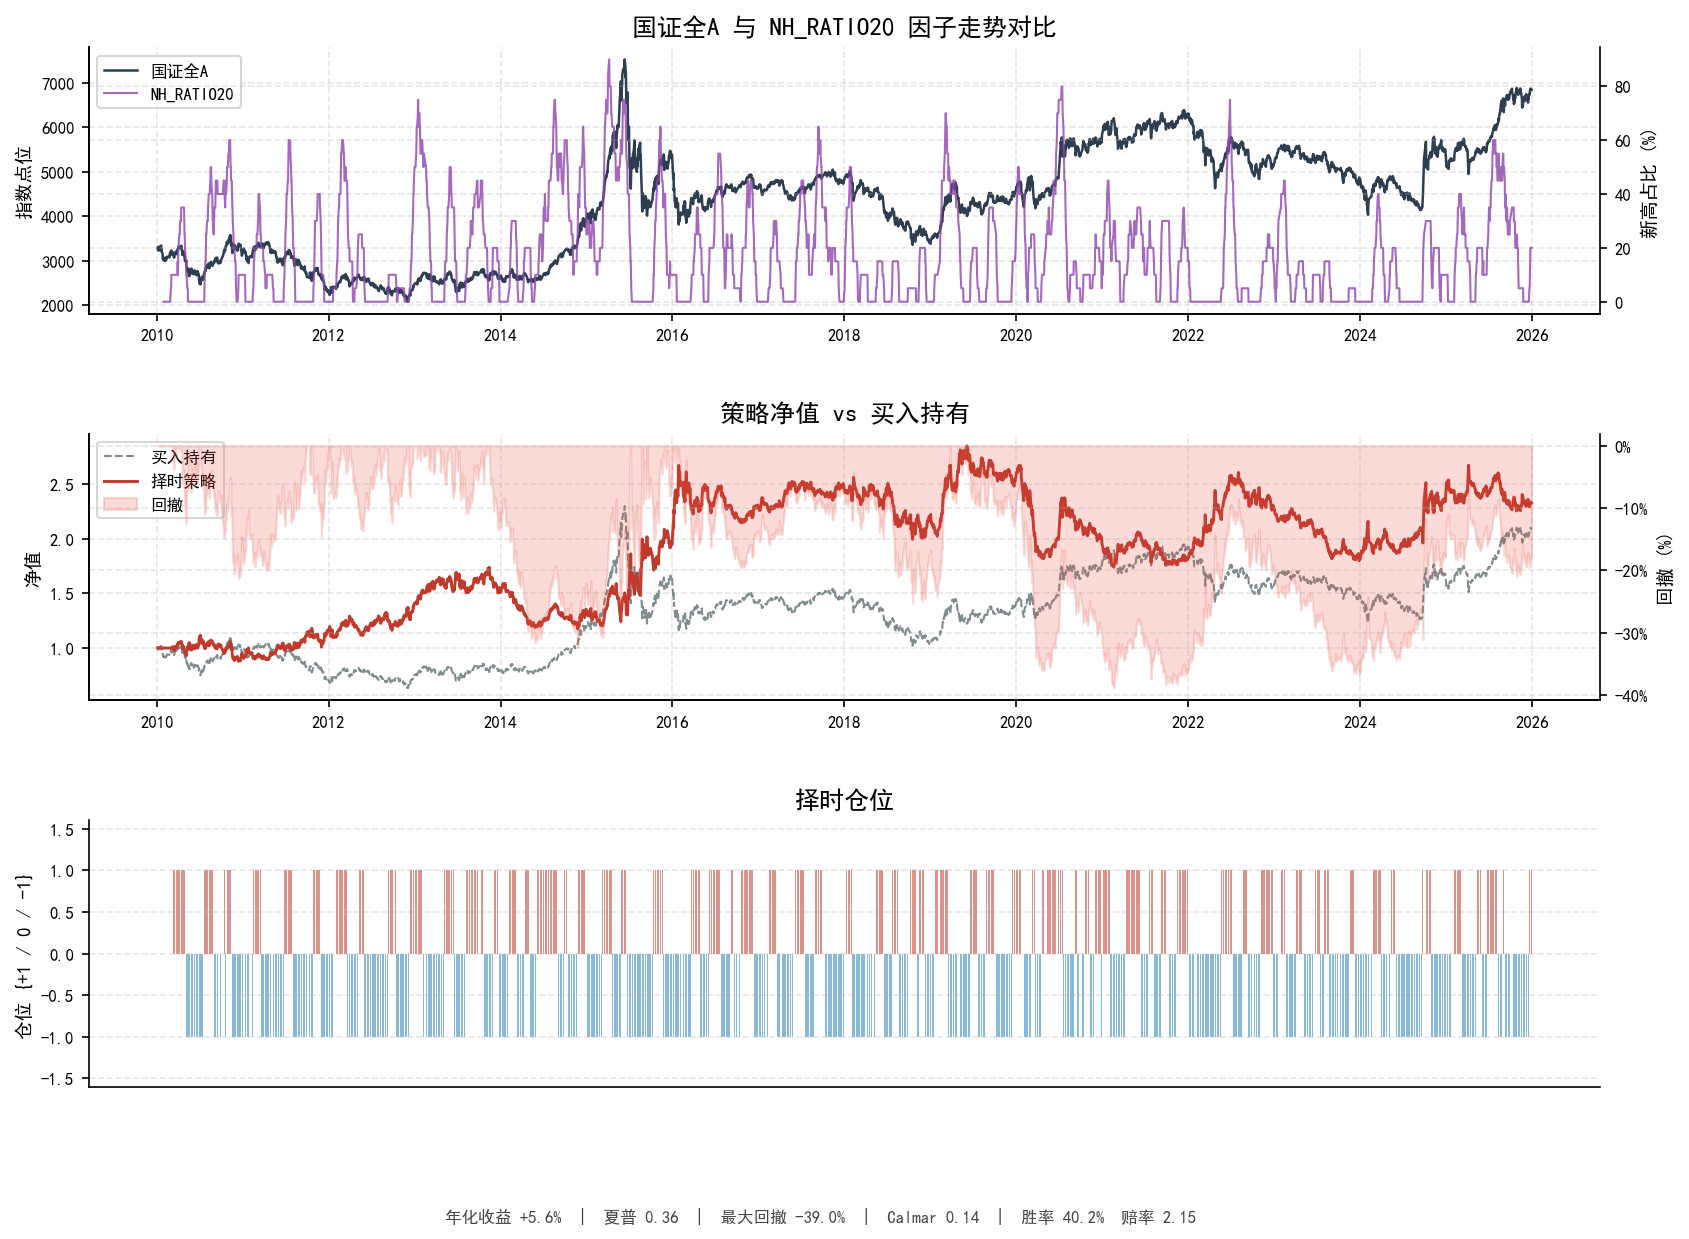

In [27]:
factor_nh = new_high_ratio(close, n=20)
res4 = run_strategy(close, factor_nh, 'BOLL', smooth_n=1, lookback=20,
                    k=1.0, cost_bps=5.0, name='NH_RATIO20')
plot_factor_backtest(res4, 'NH_RATIO20', '新高占比 (%)', C['factor'])

### 3.5  IV20 — 50ETF 期权隐含波动率

**择时逻辑**：隐波上升→市场恐慌，布林带捕捉超跌后反弹（正向BOLL）。

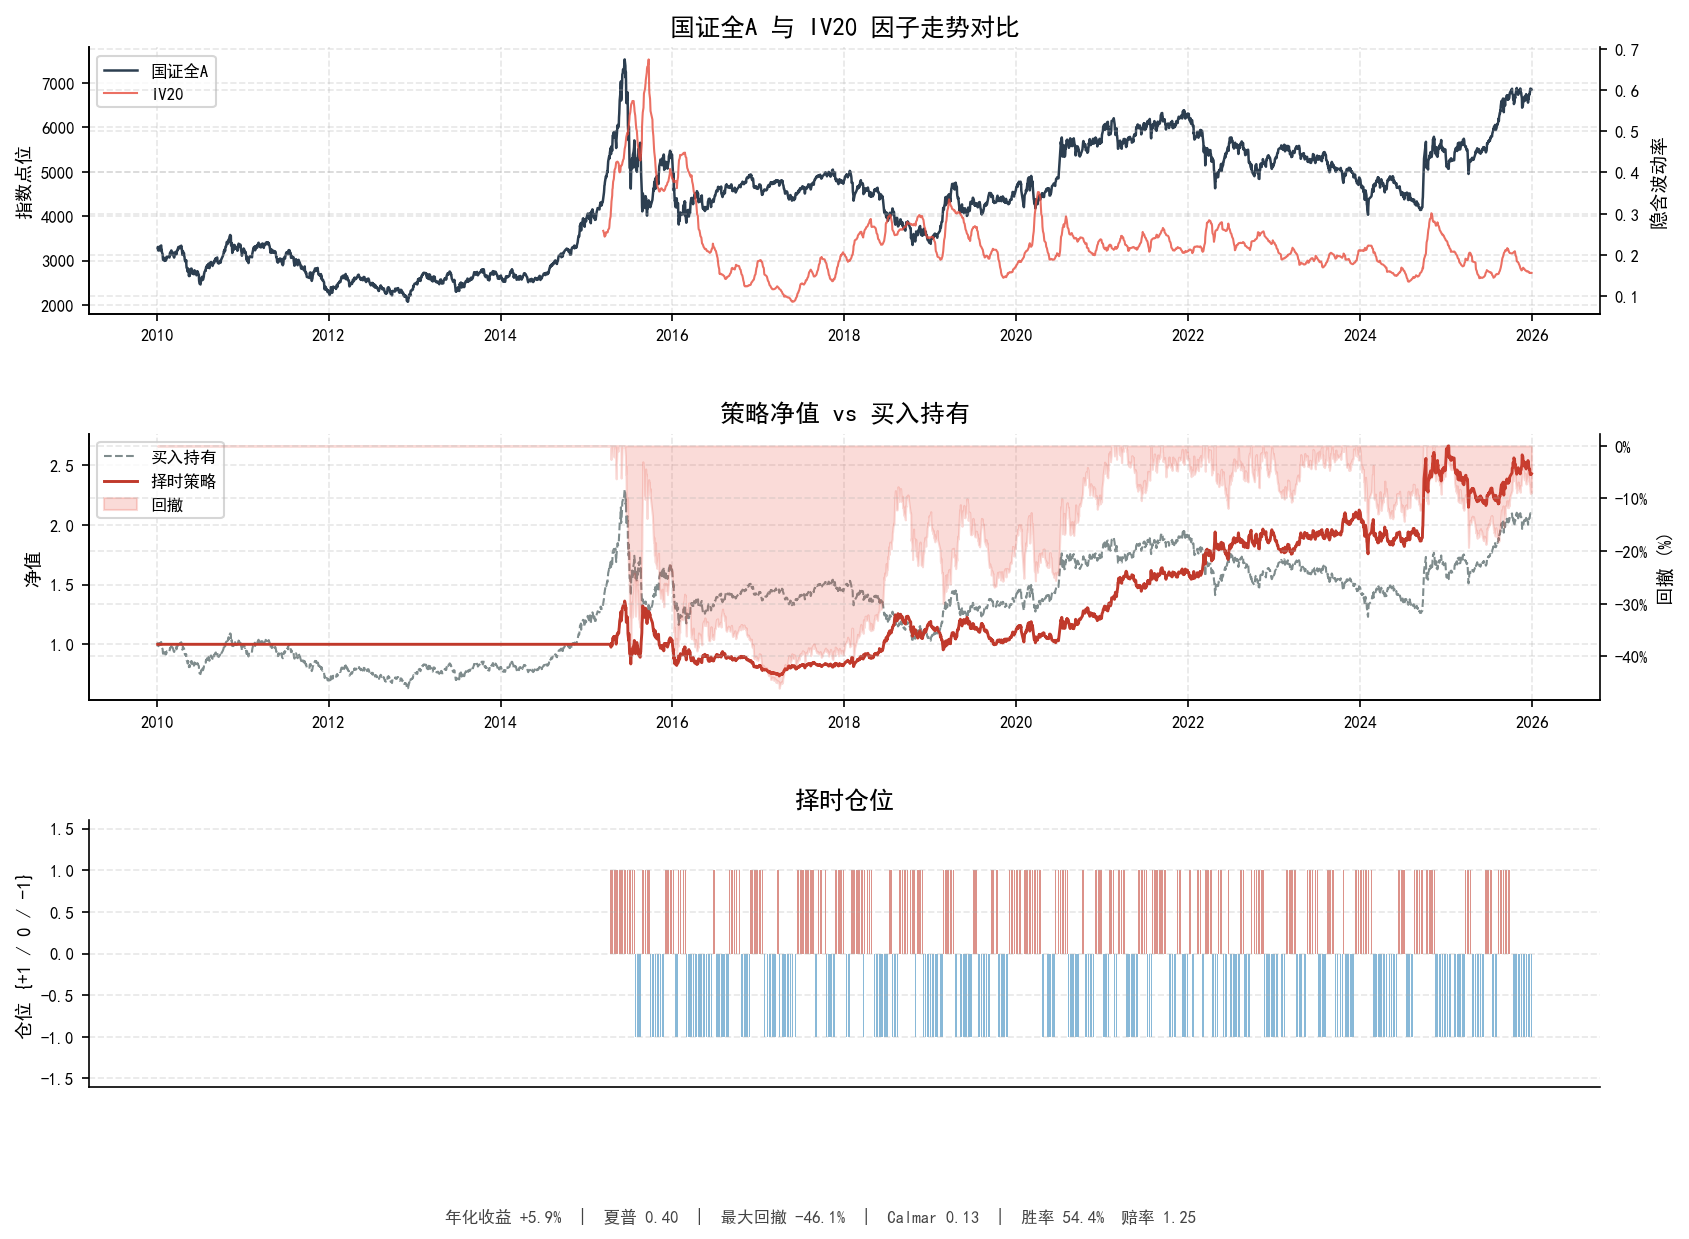

In [28]:
daily_iv     = implied_volatility.groupby('TRADE_DATE')['IMPLC_VOLATLTY'].mean()
daily_iv.index = pd.to_datetime(daily_iv.index)
factor_iv20  = implied_vol_factor(daily_iv, n=20)
res5 = run_strategy(close, factor_iv20, 'BOLL', smooth_n=1, lookback=20,
                    k=1.0, cost_bps=5.0, name='IV20')
plot_factor_backtest(res5, 'IV20', '隐含波动率', C['dd'])

### 3.6  LU_RATIO5 — 成分股涨停占比5日均值

**择时逻辑**：涨停比例高→市场做多情绪强，布林带跟踪量能拥挤度。

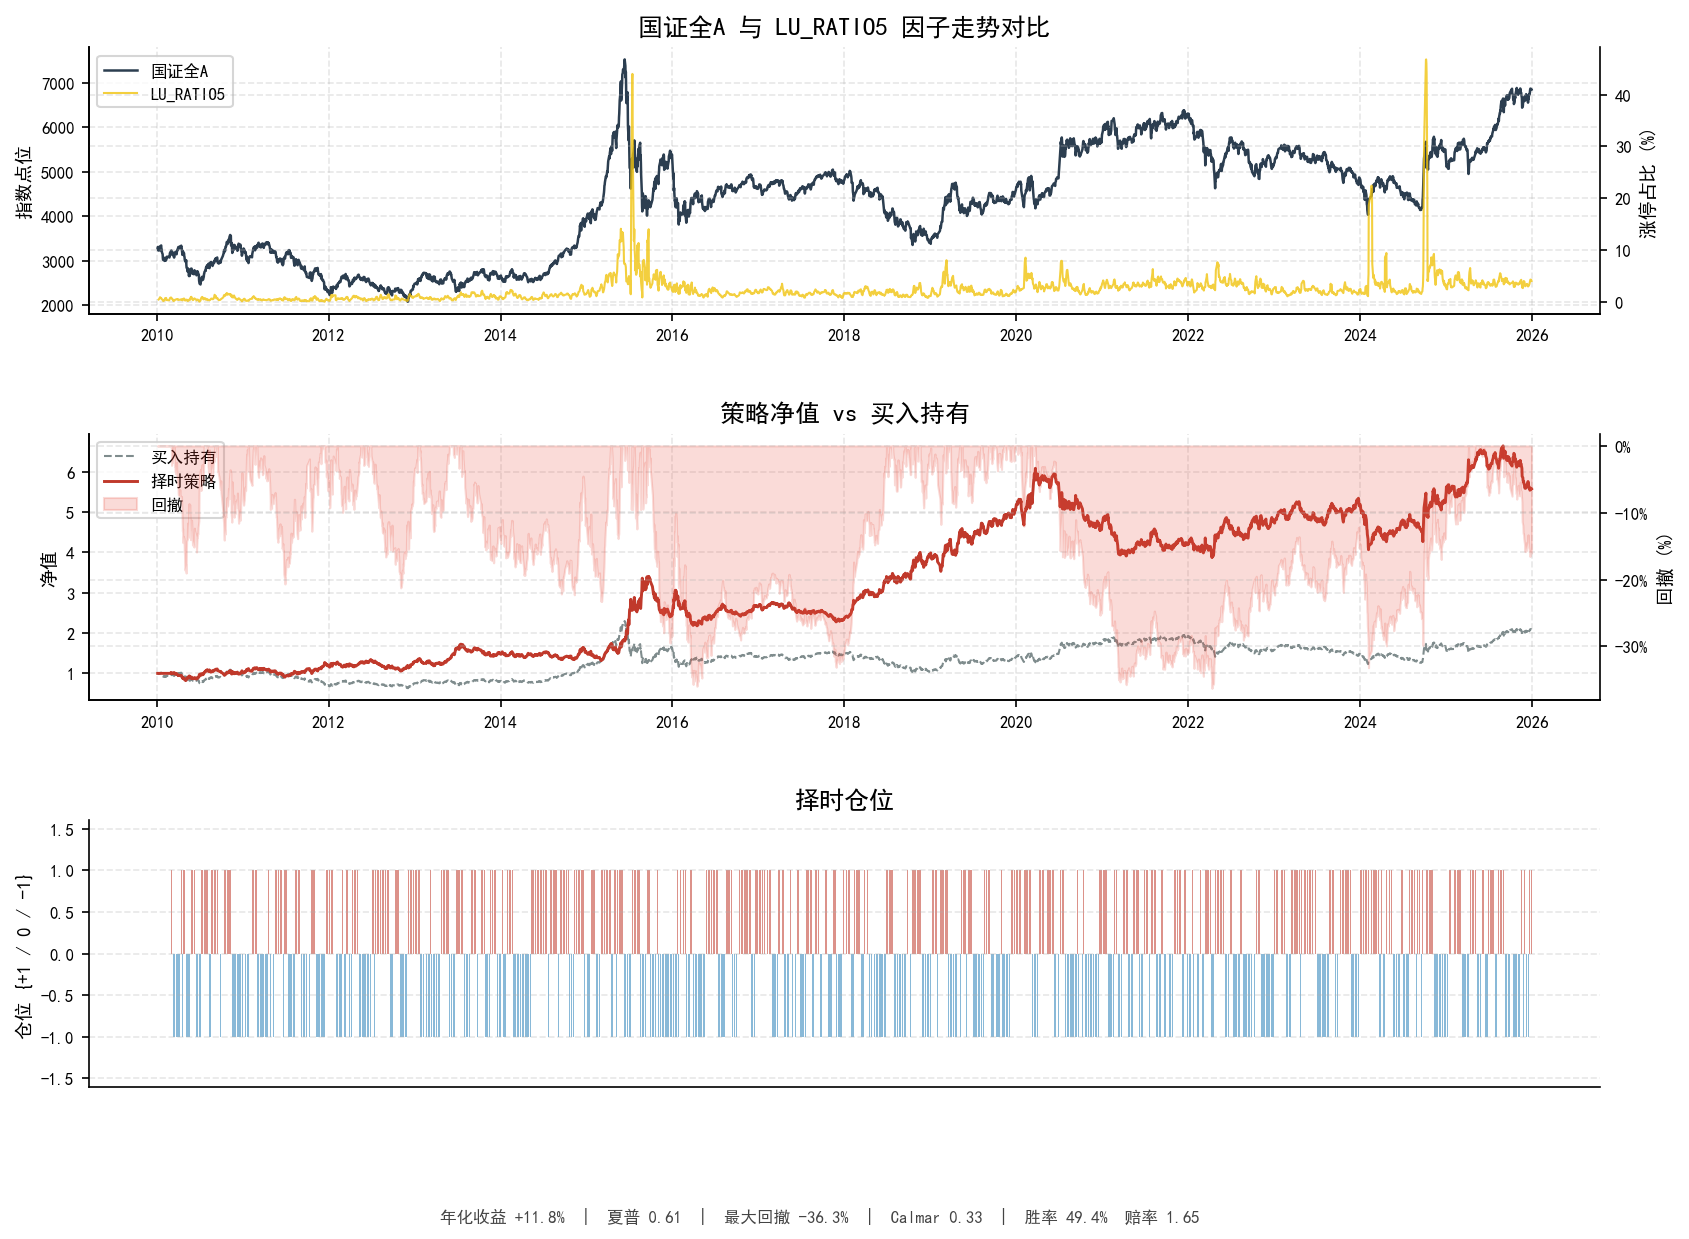

In [29]:
cs = constituent_stock.copy()
cs['date'] = pd.to_datetime(cs['date'])
cs['is_lu'] = (cs['pctChg'] >= 9.8).astype(int)
daily_lu  = cs.groupby('date')['is_lu'].sum()
n_total   = int(cs.groupby('date').size().mode()[0])
factor_lu = limit_up_ratio(daily_lu, n_total, n=5)
res6 = run_strategy(close, factor_lu, 'BOLL', smooth_n=1, lookback=20,
                    k=1.0, cost_bps=5.0, name='LU_RATIO5')
plot_factor_backtest(res6, 'LU_RATIO5', '涨停占比 (%)', C['yellow'])

### 3.7  单指标绩效汇总

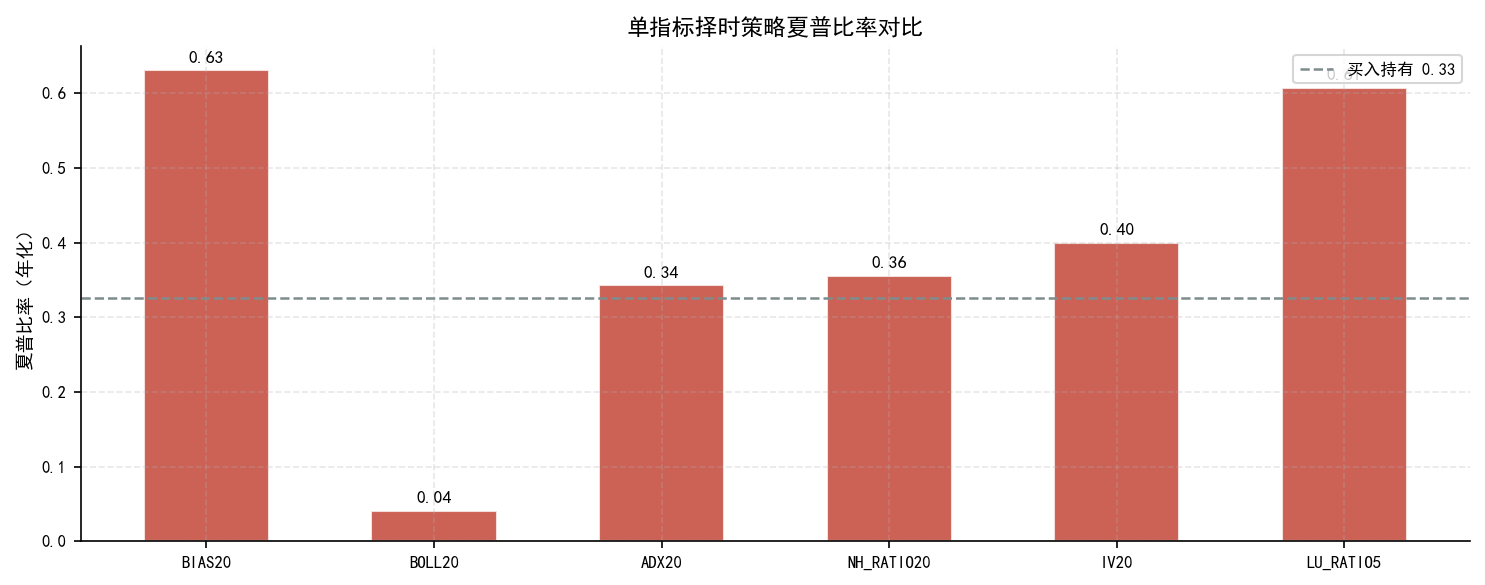


单指标绩效汇总：
              年化收益    年化波动     最大回撤  夏普比率 Calmar比率      胜率    赔率
BIAS20      12.32%  22.34%  -39.47%  0.63     0.31  40.83%  2.15
BOLL20      -1.57%  22.42%  -52.10%  0.04    -0.03  44.14%  1.39
ADX20        5.32%  22.53%  -57.28%  0.34     0.09  58.54%  0.92
NH_RATIO20   5.63%  22.49%  -38.95%  0.36     0.14  40.16%  2.15
IV20         5.92%  18.83%  -46.09%  0.40     0.13  54.44%  1.25
LU_RATIO5   11.79%  22.49%  -36.26%  0.61     0.33  49.35%  1.65


In [30]:
results = {'BIAS20':res1,'BOLL20':res2,'ADX20':res3,
            'NH_RATIO20':res4,'IV20':res5,'LU_RATIO5':res6}

_cols = ['年化收益','年化波动','最大回撤','夏普比率','Calmar比率',
         '持仓均值','持仓中位','胜率','赔率','段数']
perf_df = pd.DataFrame({k: {c: v['stats'].get(c) for c in _cols}
                         for k,v in results.items()}).T

# 格式化
fmt = perf_df.copy()
for c in ['年化收益','年化波动','最大回撤','胜率']:
    fmt[c] = perf_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
for c in ['夏普比率','Calmar比率','赔率']:
    fmt[c] = perf_df[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
for c in ['持仓均值','持仓中位','段数']:
    fmt[c] = perf_df[c].map(lambda x: f'{x:.1f}' if pd.notna(x) else '—')

# ── 可视化：夏普比率对比 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sharpes = perf_df['夏普比率']
colors  = [C['bull'] if v > 0 else C['bear'] for v in sharpes]
bars = ax.bar(sharpes.index, sharpes.values, color=colors, alpha=0.8,
              edgecolor='white', width=0.55)
# benchmark line
bm_sharpe = (close.pct_change().dropna().mean() /
             close.pct_change().dropna().std(ddof=0) * np.sqrt(TRADING_DAYS))
ax.axhline(bm_sharpe, ls='--', color=C['bench'], lw=1.2, label=f'买入持有 {bm_sharpe:.2f}')
for bar, v in zip(bars, sharpes.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+(0.01 if v>=0 else -0.04),
            f'{v:.2f}', ha='center', fontsize=8.5, fontweight='bold')
ax.set_ylabel('夏普比率（年化）')
ax.set_title('单指标择时策略夏普比率对比', fontweight='bold', fontsize=11)
ax.legend()
plt.tight_layout(); plt.show()

print('\n单指标绩效汇总：')
print(fmt[['年化收益','年化波动','最大回撤','夏普比率','Calmar比率','胜率','赔率']].to_string())

## 4  市场打分体系与综合择时策略

参照华泰研报《A股择时之技术打分体系》，将 6 个维度的单指标信号**等权平均**，
形成综合技术打分 ∈ [−1, +1]：

| 维度 | 指标 | 信号方向 |
|------|------|----------|
| 价格 | BIAS20 | 正向 |
| 价格 | BOLL20 | 正向 |
| 趋势 | ADX20  | 正向 |
| 趋势 | NH_RATIO20 | 正向（仅多） |
| 波动 | IV20   | 正向 |
| 拥挤 | LU_RATIO5 | 正向 |

**信号1（严格版）**：得分 > +1/3 → 做多；< −1/3 → 做空；其余观望  
**信号2（宽松版）**：得分 > 0 → 做多；≤ 0 → 做空（无观望，减少震荡市摩擦）

In [31]:
# ── 步骤1：汇总六个指标信号矩阵 ─────────────────────────────────────────
sig_df = pd.DataFrame({
    'BIAS20':     res1['signal'],
    'BOLL20':     res2['signal'],
    'ADX20':      res3['signal'],
    'NH_RATIO20': res4['signal'],
    'IV20':       res5['signal'],
    'LU_RATIO5':  res6['signal'],
}).reindex(close.index).fillna(0).astype(int)

# ── 步骤2：综合打分 ──────────────────────────────────────────────────────
THRESHOLD = 1/3
score   = sig_df.mean(axis=1).rename('综合打分')

signal1 = pd.cut(score, bins=[-1.1,-THRESHOLD,THRESHOLD,1.1],
                 labels=[-1,0,1]).astype(float).astype(int)
signal1.name = '信号1'

signal2 = (score > 0).astype(int)*2 - 1
signal2.name = '信号2'

# ── 步骤3：回测 ──────────────────────────────────────────────────────────
COST = 5.0 / 1e4          # 与单指标保持一致

bt1  = backtest(close, signal1, cost_bps=COST)
bt2  = backtest(close, signal2, cost_bps=COST)
nav1, nav2 = bt1['nav'], bt2['nav']
dd1,  dd2  = nav1/nav1.cummax()-1, nav2/nav2.cummax()-1
nav_bm     = close / close.iloc[0]
dd_bm      = nav_bm / nav_bm.cummax() - 1

stats1 = calc_stats(bt1, nav1)
stats2 = calc_stats(bt2, nav2)

bm_ret    = close.pct_change().fillna(0)
stats_bm  = {
    '年化收益': nav_bm.iloc[-1]**(TRADING_DAYS/max(len(nav_bm)-1,1))-1,
    '年化波动': bm_ret.std(ddof=0)*np.sqrt(TRADING_DAYS),
    '最大回撤': dd_bm.min(),
    '夏普比率': bm_ret.mean()/bm_ret.std(ddof=0)*np.sqrt(TRADING_DAYS),
    'Calmar比率': ((nav_bm.iloc[-1]**(TRADING_DAYS/max(len(nav_bm)-1,1))-1)
                  /abs(dd_bm.min()) if dd_bm.min()<0 else np.nan),
    '胜率':np.nan,'赔率':np.nan,'持仓均值':np.nan,'持仓中位':np.nan,'段数':np.nan,
}
print('综合打分统计：')
print(score.describe().round(3).to_frame().T.to_string(index=False))
print(f'\n信号1 — 多:{(signal1==1).mean():.1%}  观望:{(signal1==0).mean():.1%}  空:{(signal1==-1).mean():.1%}')
print(f'信号2 — 多:{(signal2==1).mean():.1%}  空:{(signal2==-1).mean():.1%}')

综合打分统计：
 count   mean   std  min    25%    50%   75%  max
3886.0 -0.093 0.458 -1.0 -0.333 -0.167 0.167  1.0

信号1 — 多:13.8%  观望:43.8%  空:42.4%
信号2 — 多:31.4%  空:68.6%


### 4.1  综合打分走势与指数对比

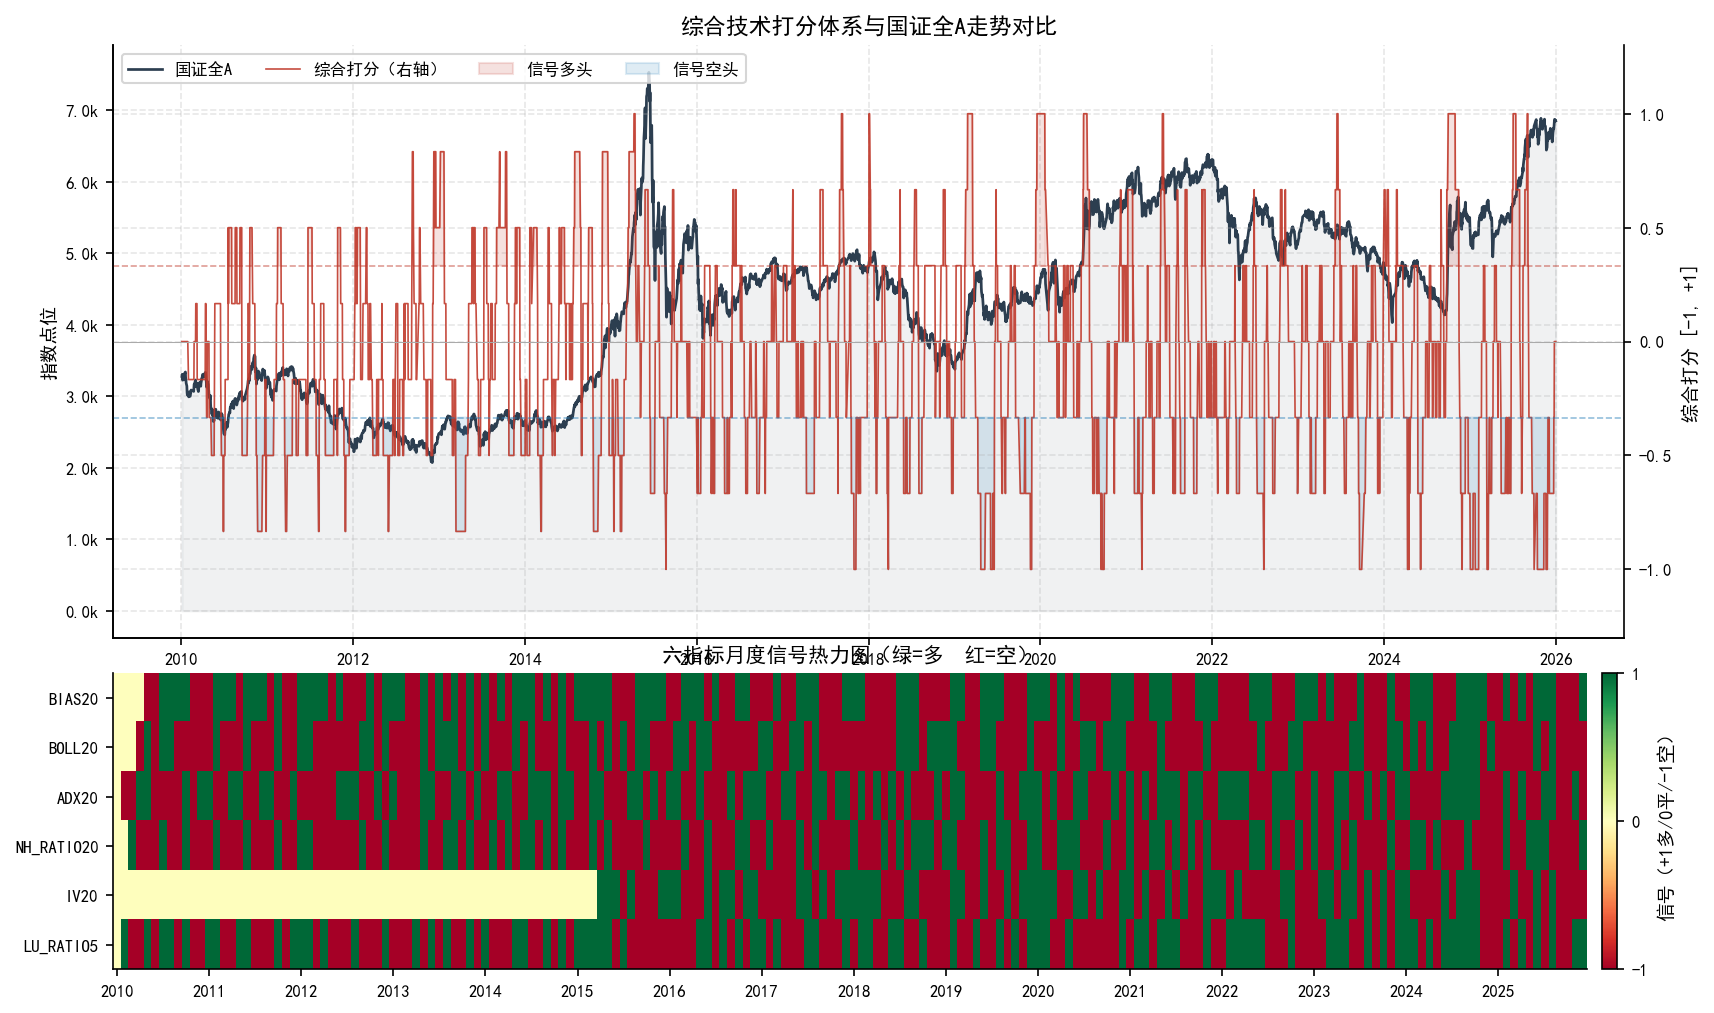

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), 
                         gridspec_kw={'height_ratios':[2,1],'hspace':0.08})

# #── 上图：指数 ────────────────────────────────────────────────────────────
ax = axes[0]; axr = ax.twinx()
ax.fill_between(close.index.to_numpy(), close.values, alpha=0.07, color=C['index'])
ax.plot(close.index.to_numpy(), close.values, color=C['index'], lw=1.3, label='国证全A')
ax.set_ylabel('指数点位', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.1f}k'))


# 多空背景色
sc = score.reindex(close.index)
axr.fill_between(close.index.to_numpy(), sc.values, THRESHOLD,
                 where=sc.values>THRESHOLD, color=C['bull'], alpha=0.15, label='信号多头')
axr.fill_between(close.index.to_numpy(), sc.values,-THRESHOLD,
                 where=sc.values<-THRESHOLD, color=C['bear'], alpha=0.15, label='信号空头')
axr.plot(close.index.to_numpy(), sc.values, color=C['bull'], lw=0.8, alpha=0.9, label='综合打分（右轴）')
axr.axhline( THRESHOLD, ls='--', color=C['bull'],  lw=0.8, alpha=0.5)
axr.axhline(-THRESHOLD, ls='--', color=C['bear'], lw=0.8, alpha=0.5)
axr.axhline(0, ls='-', color='#aaa', lw=0.5)
axr.set_ylim(-1.3, 1.3); axr.set_ylabel('综合打分 [-1, +1]')
axr.spines['right'].set_visible(True)

h1,l1=ax.get_legend_handles_labels(); h2,l2=axr.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper left', ncol=4)
ax.set_title('综合技术打分体系与国证全A走势对比', fontweight='bold', fontsize=11)

# ── 下图：六指标信号热力图 ─────────────────────────────────────────────────
ax2 = axes[1]
monthly = sig_df.resample('ME').last()
im = ax2.imshow(monthly.T.values.astype(float), aspect='auto',
                cmap='RdYlGn', vmin=-1, vmax=1, interpolation='nearest')
ax2.set_yticks(range(len(sig_df.columns)))
ax2.set_yticklabels(sig_df.columns, fontsize=8)
yr_idx, yr_lbl = [], []
for i, dt in enumerate(monthly.index):
    if dt.month == 1 or i == 0:
        yr_idx.append(i); yr_lbl.append(str(dt.year))
ax2.set_xticks(yr_idx); ax2.set_xticklabels(yr_lbl, fontsize=8)
plt.colorbar(im, ax=ax2, fraction=0.015, pad=0.01,
             ticks=[-1,0,1], label='信号（+1多/0平/-1空）')
ax2.set_title('六指标月度信号热力图（绿=多  红=空）', fontweight='bold', fontsize=10)
ax2.grid(False)

#plt.savefig('/tmp/score_vs_index.png', bbox_inches='tight')
plt.show()

### 4.2  综合策略净值曲线

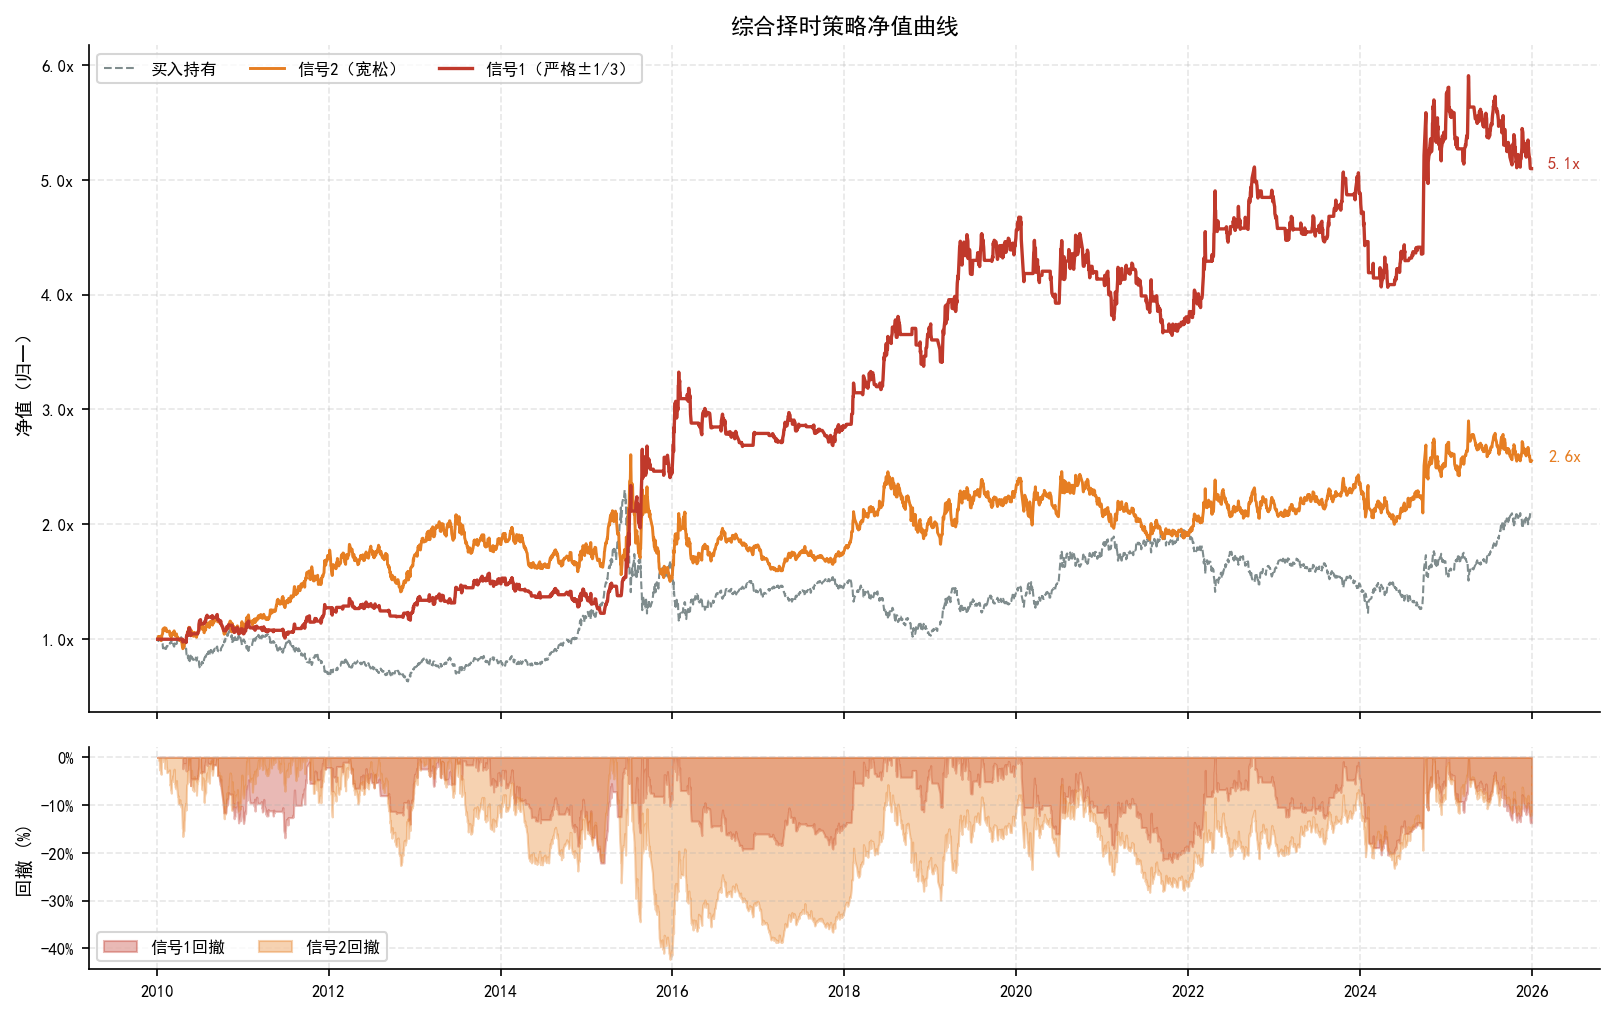

In [52]:
t0 = max(nav1.index[0], nav2.index[0])
n1  = nav1.loc[t0:]; n2  = nav2.loc[t0:]
nbm = nav_bm.loc[t0:] / nav_bm.loc[t0]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                         gridspec_kw={'height_ratios':[3,1],'hspace':0.08},
                         sharex=True)

# ── 净值 ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(nbm.index.to_numpy(), nbm.values, color=C['bench'], lw=1.0, ls='--', label='买入持有')
ax.plot(n2.index.to_numpy(),  n2.values,  color=C['sig2'],  lw=1.4, label='信号2（宽松）')
ax.plot(n1.index.to_numpy(),  n1.values,  color=C['bull'],  lw=1.6, label='信号1（严格±1/3）')

# 注释最终净值
for nav_s, clr, lbl in [(n1,C['bull'],'信号1'),(n2,C['sig2'],'信号2')]:
    ax.annotate(f'{nav_s.iloc[-1]:.1f}x',
                xy=(nav_s.index[-1], nav_s.iloc[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8, color=clr, fontweight='bold')

ax.set_ylabel('净值（归一）')
ax.legend(loc='upper left', ncol=3)
ax.set_title('综合择时策略净值曲线', fontweight='bold', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}x'))

# ── 回撤 ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(dd1.loc[t0:].index, dd1.loc[t0:].values*100, 0,
                 color=C['bull'], alpha=0.35, label='信号1回撤')
ax2.fill_between(dd2.loc[t0:].index, dd2.loc[t0:].values*100, 0,
                 color=C['sig2'], alpha=0.35, label='信号2回撤')
ax2.set_ylabel('回撤 (%)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax2.legend(loc='lower left', ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#plt.savefig('/tmp/nav_curve.png', bbox_inches='tight')
plt.show()

### 4.3  分年度收益对比

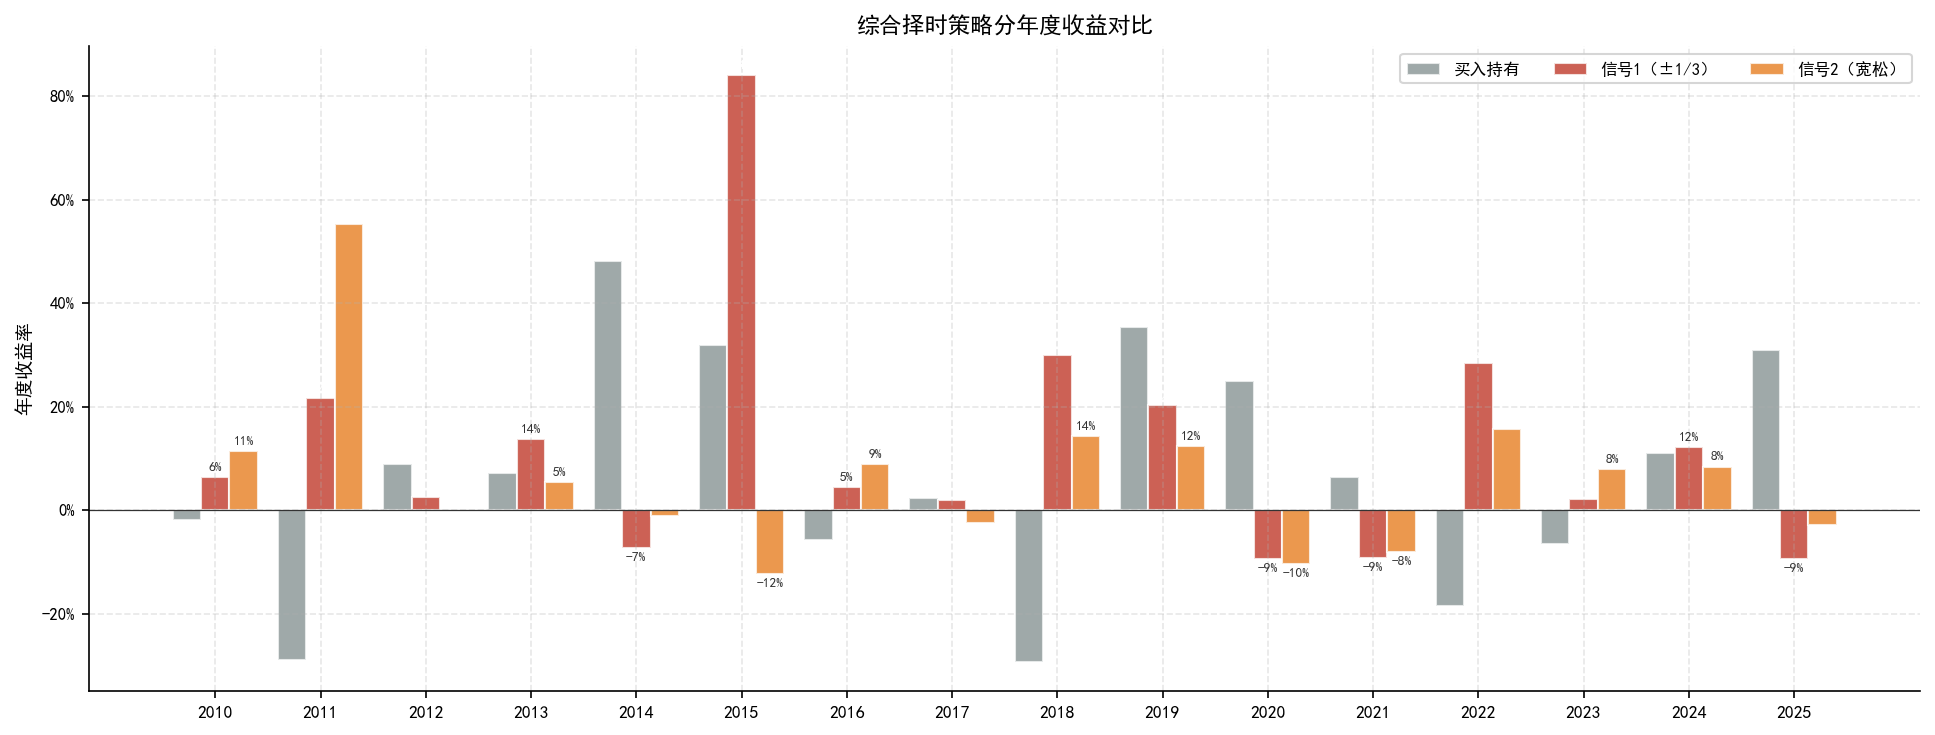

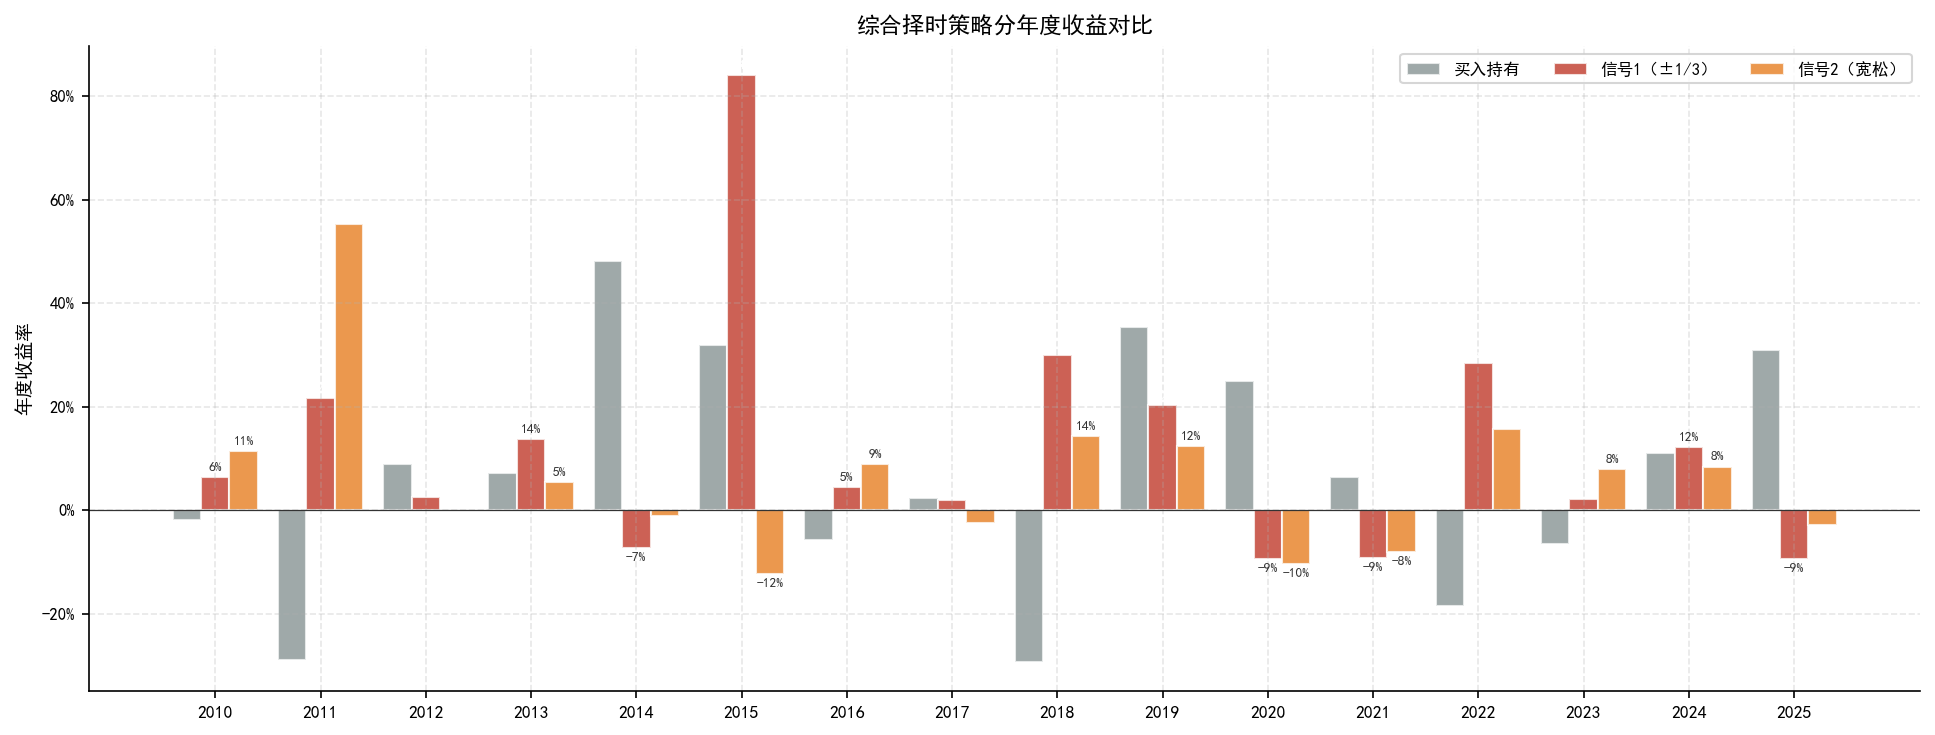

          信号1      信号2     买入持有
年份                             
2010   +6.49%  +11.40%   -1.87%
2011  +21.75%  +55.26%  -28.90%
2012   +2.57%   -0.16%   +8.97%
2013  +13.81%   +5.49%   +7.22%
2014   -7.22%   -1.09%  +48.12%
2015  +84.07%  -12.31%  +31.93%
2016   +4.57%   +9.01%   -5.64%
2017   +1.91%   -2.37%   +2.39%
2018  +29.95%  +14.29%  -29.30%
2019  +20.34%  +12.41%  +35.44%
2020   -9.36%  -10.44%  +25.08%
2021   -9.15%   -8.00%   +6.54%
2022  +28.52%  +15.66%  -18.46%
2023   +2.27%   +7.90%   -6.40%
2024  +12.24%   +8.48%  +11.16%
2025   -9.39%   -2.90%  +30.89%


In [42]:
def annual_ret(nav_s):
    return pd.Series({yr: (sub.iloc[-1]/sub.iloc[0]-1)
                      for yr in sorted(set(nav_s.index.year))
                      for sub in [nav_s[nav_s.index.year==yr]]
                      if len(sub)>=2})

ann1 = annual_ret(nav1); ann2 = annual_ret(nav2); ann_bm = annual_ret(nav_bm)
yrs  = sorted(set(ann1.index)&set(ann2.index)&set(ann_bm.index))
x, w = np.arange(len(yrs)), 0.27

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w,   [ann_bm.get(y,0) for y in yrs], w, label='买入持有',
       color=C['bench'], alpha=0.75, edgecolor='white')
bars1 = ax.bar(x,   [ann1.get(y,0) for y in yrs], w, label='信号1（±1/3）',
               color=C['bull'],  alpha=0.80, edgecolor='white')
bars2 = ax.bar(x+w, [ann2.get(y,0) for y in yrs], w, label='信号2（宽松）',
               color=C['sig2'], alpha=0.80, edgecolor='white')

ax.axhline(0, color='#333', lw=0.6)
# 标注年度收益
for bars, data in [(bars1,ann1),(bars2,ann2)]:
    for bar, yr in zip(bars, yrs):
        v = data.get(yr,0)
        if abs(v) > 0.03:
            ax.text(bar.get_x()+bar.get_width()/2,
                    v+(0.012 if v>=0 else -0.025),
                    f'{v:.0%}', ha='center', fontsize=6.5, fontweight='bold',
                    color='white' if abs(v)>0.15 else '#333')

ax.set_xticks(x); ax.set_xticklabels(yrs, fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_ylabel('年度收益率')
ax.set_title('综合择时策略分年度收益对比', fontweight='bold', fontsize=11)
ax.legend(ncol=3)
plt.tight_layout()
#plt.savefig('/tmp/annual_ret.png', bbox_inches='tight')
plt.show()

# 数字表
ann_tbl = pd.DataFrame({'信号1':ann1,'信号2':ann2,'买入持有':ann_bm})
ann_tbl.index.name='年份'
print(ann_tbl.applymap(lambda v: f'{v:+.2%}' if pd.notna(v) else '—').to_string())

### 4.4  完整绩效汇总

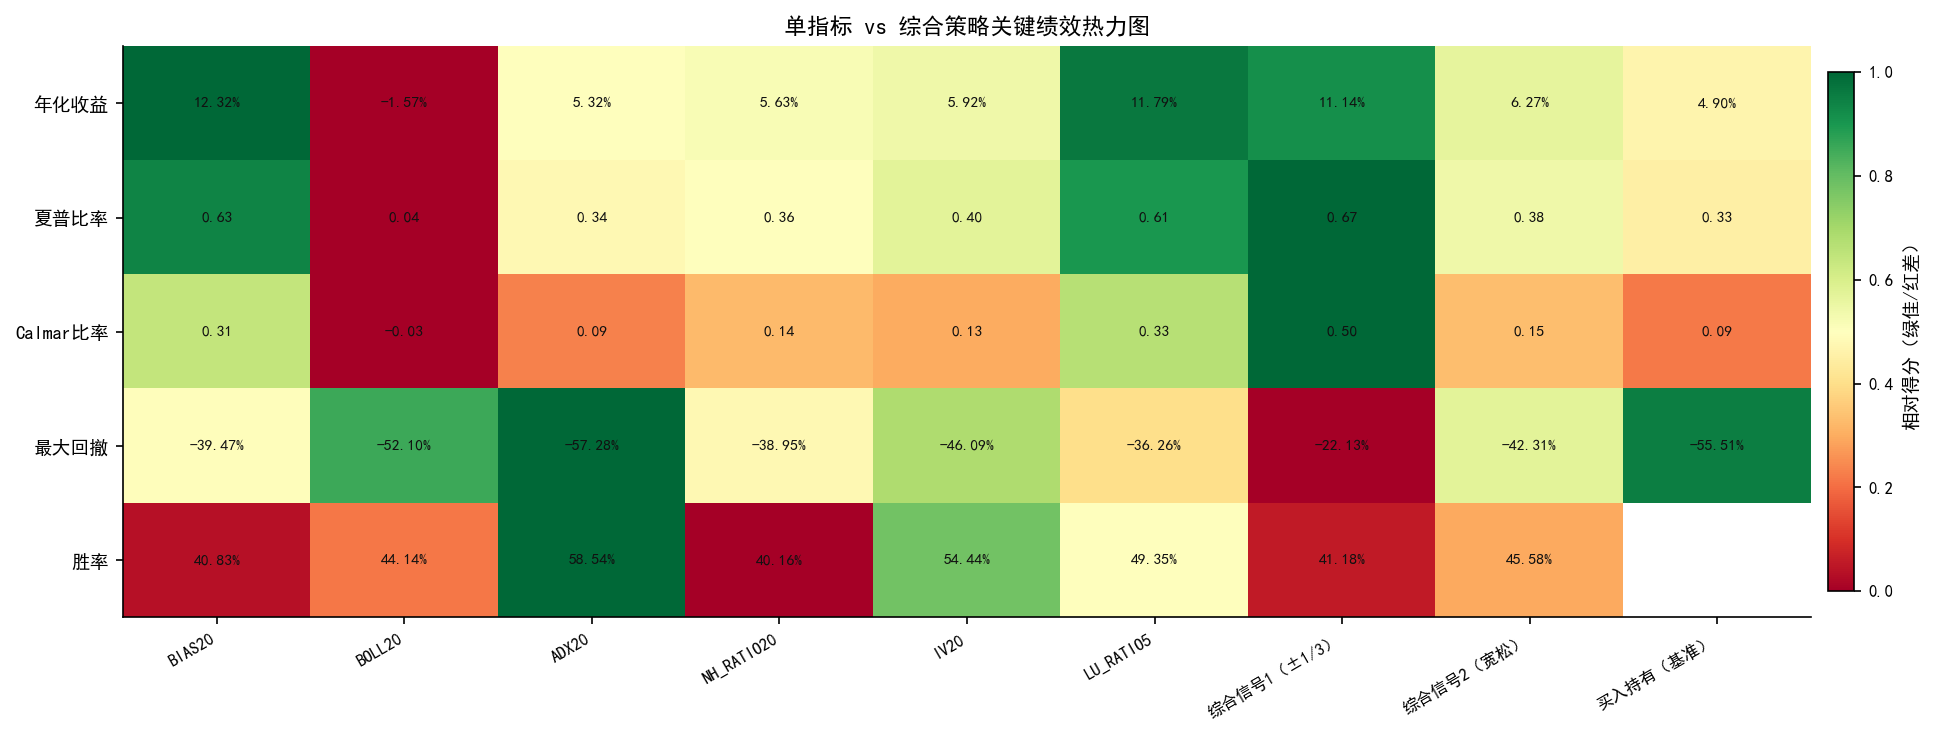


完整绩效汇总：
               年化收益    年化波动     最大回撤  夏普比率 Calmar比率      胜率    赔率
BIAS20       12.32%  22.34%  -39.47%  0.63     0.31  40.83%  2.15
BOLL20       -1.57%  22.42%  -52.10%  0.04    -0.03  44.14%  1.39
ADX20         5.32%  22.53%  -57.28%  0.34     0.09  58.54%  0.92
NH_RATIO20    5.63%  22.49%  -38.95%  0.36     0.14  40.16%  2.15
IV20          5.92%  18.83%  -46.09%  0.40     0.13  54.44%  1.25
LU_RATIO5    11.79%  22.49%  -36.26%  0.61     0.33  49.35%  1.65
综合信号1（±1/3）  11.14%  18.21%  -22.13%  0.67     0.50  41.18%  2.34
综合信号2（宽松）     6.27%  22.59%  -42.31%  0.38     0.15  45.58%  1.39
买入持有（基准）      4.90%  22.60%  -55.51%  0.33     0.09       —     —


In [43]:
_cols = ['年化收益','年化波动','最大回撤','夏普比率','Calmar比率',
         '持仓均值','持仓中位','胜率','赔率','段数']

perf_all = pd.DataFrame({
    **{k:{c:v['stats'].get(c) for c in _cols} for k,v in results.items()},
    '综合信号1（±1/3）': {c:stats1.get(c) for c in _cols},
    '综合信号2（宽松）':  {c:stats2.get(c) for c in _cols},
    '买入持有（基准）':   {c:stats_bm.get(c) for c in _cols},
}).T

# 格式化
fmt_all = perf_all.copy()
for c in ['年化收益','年化波动','最大回撤','胜率']:
    fmt_all[c] = perf_all[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
for c in ['夏普比率','Calmar比率','赔率']:
    fmt_all[c] = perf_all[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
for c in ['持仓均值','持仓中位','段数']:
    fmt_all[c] = perf_all[c].map(lambda x: f'{x:.0f}' if pd.notna(x) else '—')

# ── 可视化：关键绩效对比热力图 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
kpi_cols = ['年化收益','夏普比率','Calmar比率','最大回撤','胜率']
kpi_num  = perf_all[kpi_cols].astype(float)

# 逐列归一化（0—1），回撤取反
norm_m = kpi_num.copy()
for c in kpi_cols:
    col = kpi_num[c].dropna()
    lo, hi = col.min(), col.max()
    if hi > lo:
        norm_m[c] = (kpi_num[c]-lo)/(hi-lo)
    else:
        norm_m[c] = 0.5
if '最大回撤' in norm_m:
    norm_m['最大回撤'] = 1 - norm_m['最大回撤']   # 回撤越小越好

im = ax.imshow(norm_m.values.T, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(norm_m.index)))
ax.set_xticklabels(norm_m.index, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(kpi_cols)))
ax.set_yticklabels(kpi_cols, fontsize=9)

# 叠加原始数值
for i in range(len(norm_m.index)):
    for j, c in enumerate(kpi_cols):
        v = kpi_num.iloc[i][c]
        if pd.notna(v):
            txt = (f'{v:.2%}' if c in ['年化收益','最大回撤','胜率']
                   else f'{v:.2f}')
            ax.text(i, j, txt, ha='center', va='center',
                    fontsize=7.5, color='#111')

plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='相对得分（绿佳/红差）')
ax.set_title('单指标 vs 综合策略关键绩效热力图', fontweight='bold', fontsize=11)
ax.grid(False)
plt.tight_layout()
#plt.savefig('/tmp/perf_heatmap.png', bbox_inches='tight')
plt.show()

print('\n完整绩效汇总：')
print(fmt_all[['年化收益','年化波动','最大回撤','夏普比率','Calmar比率','胜率','赔率']].to_string())